Install the dataset loader

In [1]:
!pip -q install ucimlrepo

Load the dataset directly

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

heart_data = fetch_ucirepo(id=45)

X = heart_data.data.features.copy()
original_target = heart_data.data.targets.iloc[:, 0].copy()

# Confirm the target is present and uses the expected labels.
assert original_target.notna().all()
assert original_target.isin([0, 1, 2, 3, 4]).all()

# Binary classification:
# 0 = absence of the recorded disease label
# 1 = presence of the recorded disease label
y = (original_target > 0).astype(int)
y.name = "disease_label"

df = X.copy()
df["disease_label"] = y

print("Records:", len(df))
print("Input features:", X.shape[1])

display(df.head())

Records: 303
Input features: 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease_label
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Inspect missing values and class balance

In [3]:
print("Missing values per feature:")
display(
    X.isna().sum().rename("missing_count").to_frame()
)

print("Target counts:")
display(
    y.value_counts()
    .sort_index()
    .rename_axis("disease_label")
    .to_frame("records")
)

print("Feature data types:")
display(X.dtypes.rename("dtype").to_frame())

print("Exact duplicate rows, including target:", df.duplicated().sum())

Missing values per feature:


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Target counts:


,records
disease_label,
0,164
1,139


Feature data types:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


Exact duplicate rows, including target: 0


Reserve the test set

In [4]:
from sklearn.model_selection import train_test_split

SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training records:", len(X_train))
print("Test records:", len(X_test))

Training records: 242
Test records: 61


Define preprocessing

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca",
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal",
]

assert set(numeric_features + categorical_features) == set(X.columns)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

Create the complete model pipeline

In [6]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=SEED,
        ),
    ),
])

Evaluate using training-only cross-validation

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

logistic_cv = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    error_score="raise",
)

summary = pd.DataFrame([
    {
        "metric": metric,
        "mean": logistic_cv[f"test_{metric}"].mean(),
        "fold_std": logistic_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
])

display(summary.round(3))

,metric,mean,fold_std
0,accuracy,0.847,0.022
1,precision,0.878,0.071
2,recall,0.784,0.034
3,f1,0.825,0.015
4,roc_auc,0.906,0.020


Fit the baseline on all training records

In [8]:
logistic_model.fit(X_train, y_train)

print("Baseline model fitted successfully.")

Baseline model fitted successfully.


Understand Random Forest
Build its preprocessing and model

In [9]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

# Trees do not need numeric scaling.
forest_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

forest_preprocessor = ColumnTransformer([
    (
        "numeric",
        forest_numeric_pipeline,
        numeric_features,
    ),
    (
        "categorical",
        clone(categorical_pipeline),
        categorical_features,
    ),
])

forest_model = Pipeline([
    ("preprocessing", forest_preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=-1,
        ),
    ),
])

Evaluate on the same cross-validation folds

In [10]:
forest_cv = cross_validate(
    forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    error_score="raise",
)

comparison_rows = []

for name, results in [
    ("Logistic Regression", logistic_cv),
    ("Random Forest", forest_cv),
]:
    row = {"model": name}

    for metric in scoring:
        row[metric] = results[f"test_{metric}"].mean()

    row["roc_auc_fold_std"] = results["test_roc_auc"].std()
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)

display(comparison.round(3))

,model,accuracy,precision,recall,f1,roc_auc,roc_auc_fold_std
0,Logistic Regression,0.847,0.878,0.784,0.825,0.906,0.020
1,Random Forest,0.826,0.834,0.783,0.804,0.900,0.026


Fit the selected pipeline and predict

In [11]:
from sklearn.base import clone

final_model = clone(logistic_model)
final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)

# Find the probability column corresponding to class 1.
positive_index = list(final_model.classes_).index(1)

test_probabilities = final_model.predict_proba(X_test)[
    :, positive_index
]

Calculate final test metrics

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_predictions),
    "precision": precision_score(
        y_test, test_predictions, zero_division=0
    ),
    "recall": recall_score(
        y_test, test_predictions, zero_division=0
    ),
    "f1": f1_score(
        y_test, test_predictions, zero_division=0
    ),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
}

display(
    pd.DataFrame(
        test_metrics.items(),
        columns=["metric", "test_score"],
    ).round(3)
)

print(
    classification_report(
        y_test,
        test_predictions,
        labels=[0, 1],
        target_names=["Label absent", "Label present"],
        zero_division=0,
    )
)

,metric,test_score
0,accuracy,0.869
1,precision,0.812
2,recall,0.929
3,f1,0.867
4,roc_auc,0.958


               precision    recall  f1-score   support

 Label absent       0.93      0.82      0.87        33
Label present       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



Understand the actual mistakes

In [13]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
).ravel()

mistakes_table = pd.DataFrame([
    {
        "outcome": "True negative",
        "meaning": "Actual 0, predicted 0",
        "count": tn,
    },
    {
        "outcome": "False positive",
        "meaning": "Actual 0, predicted 1",
        "count": fp,
    },
    {
        "outcome": "False negative",
        "meaning": "Actual 1, predicted 0",
        "count": fn,
    },
    {
        "outcome": "True positive",
        "meaning": "Actual 1, predicted 1",
        "count": tp,
    },
])

display(mistakes_table)

,outcome,meaning,count
0,True negative,"Actual 0, predicted 0",27
1,False positive,"Actual 0, predicted 1",6
2,False negative,"Actual 1, predicted 0",2
3,True positive,"Actual 1, predicted 1",26


Plot the confusion matrix and ROC curve

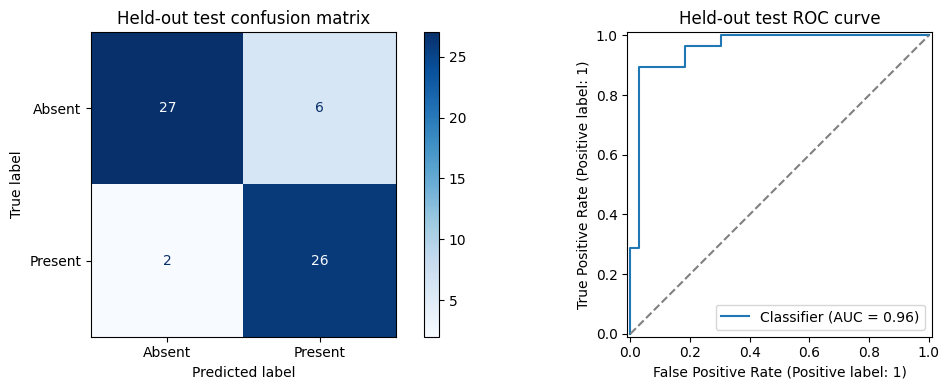

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1],
    display_labels=["Absent", "Present"],
    cmap="Blues",
    ax=axes[0],
)

axes[0].set_title("Held-out test confusion matrix")

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=axes[1],
)

axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Held-out test ROC curve")

plt.tight_layout()
plt.show()

Inspect the model’s coefficients

In [15]:
import numpy as np

fitted_preprocessor = final_model.named_steps["preprocessing"]
classifier = final_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False,
)

display(coefficient_table.head(15).round(3))

,feature,coefficient,absolute_coefficient
5,numeric__ca,1.126,1.126
11,categorical__cp_4.0,0.969,0.969
24,categorical__thal_7.0,0.801,0.801
6,categorical__sex_0.0,-0.723,0.723
7,categorical__sex_1.0,0.721,0.721
8,categorical__cp_1.0,-0.649,0.649
20,categorical__slope_2.0,0.609,0.609
22,categorical__thal_3.0,-0.561,0.561
19,categorical__slope_1.0,-0.489,0.489
10,categorical__cp_3.0,-0.478,0.478


Explain one test prediction

In [16]:
# Choose a record by its position in the test set.
record_position = 0
record = X_test.iloc[[record_position]]

prepared_record = fitted_preprocessor.transform(record)

if hasattr(prepared_record, "toarray"):
    prepared_record = prepared_record.toarray()

prepared_values = np.asarray(prepared_record)[0]
contributions = prepared_values * coefficients

log_odds = float(classifier.intercept_[0] + contributions.sum())

predicted_probability = float(
    final_model.predict_proba(record)[0, positive_index]
)

explanation_table = pd.DataFrame({
    "feature": feature_names,
    "prepared_value": prepared_values,
    "coefficient": coefficients,
    "log_odds_contribution": contributions,
})

explanation_table["absolute_contribution"] = (
    explanation_table["log_odds_contribution"].abs()
)

explanation_table = explanation_table.sort_values(
    "absolute_contribution",
    ascending=False,
)

display(record)

print("Actual label:", int(y_test.iloc[record_position]))
print("Predicted label:", int(final_model.predict(record)[0]))
print(f"Model probability for class 1: {predicted_probability:.3f}")
print(f"Intercept: {classifier.intercept_[0]:.3f}")
print(f"Total log-odds: {log_odds:.3f}")

display(explanation_table.head(10).round(3))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
219,59,1,4,138,271,0,2,182,0,0.0,1,0.0,3.0


Actual label: 0
Predicted label: 0
Model probability for class 1: 0.217
Intercept: -0.700
Total log-odds: -1.282


,feature,prepared_value,coefficient,log_odds_contribution,absolute_contribution
11,categorical__cp_4.0,1.000,0.969,0.969,0.969
5,numeric__ca,-0.690,1.126,-0.777,0.777
7,categorical__sex_1.0,1.000,0.721,0.721,0.721
22,categorical__thal_3.0,1.000,-0.561,-0.561,0.561
3,numeric__thalach,1.415,-0.359,-0.508,0.508
19,categorical__slope_1.0,1.000,-0.489,-0.489,0.489
17,categorical__exang_0.0,1.000,-0.297,-0.297,0.297
16,categorical__restecg_2.0,1.000,0.232,0.232,0.232
4,numeric__oldpeak,-0.892,0.192,-0.171,0.171
1,numeric__trestbps,0.400,0.338,0.135,0.135


Plot the largest contributions

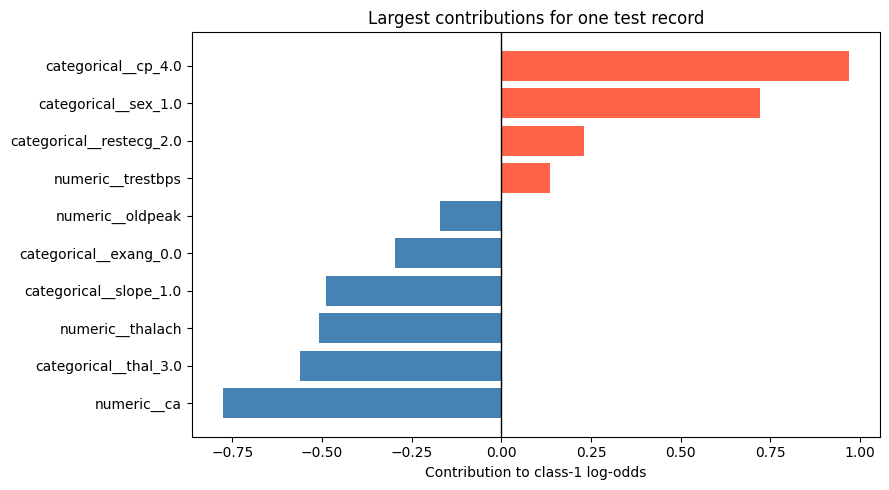

In [17]:
top_contributions = (
    explanation_table.head(10)
    .sort_values("log_odds_contribution")
)

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in top_contributions["log_odds_contribution"]
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    top_contributions["feature"],
    top_contributions["log_odds_contribution"],
    color=colors,
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Contribution to class-1 log-odds")
ax.set_title("Largest contributions for one test record")

plt.tight_layout()
plt.show()

Export the model and metadata in Colab

In [18]:
import json
import joblib
import sklearn
from pathlib import Path

EXPORT_DIR = Path("/content/heart_disease_demo")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_model,
    EXPORT_DIR / "heart_pipeline.joblib",
)

metadata = {
    "project": "Explainable Heart Disease Classification Demo",
    "model": "Logistic Regression",
    "sklearn_version": sklearn.__version__,
    "feature_columns": X_train.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "class_labels": {
        "0": "Dataset disease label absent",
        "1": "Dataset disease label present",
    },
    "decision_threshold": 0.5,
    "test_records": len(y_test),
    "test_metrics": {
        name: float(value)
        for name, value in test_metrics.items()
    },
}

(EXPORT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print("Use this scikit-learn version locally:", sklearn.__version__)
print("Exported files:", [file.name for file in EXPORT_DIR.iterdir()])

Use this scikit-learn version locally: 1.6.1
Exported files: ['metadata.json', 'heart_pipeline.joblib']


Download the two small files

In [19]:
from google.colab import files

files.download(str(EXPORT_DIR / "heart_pipeline.joblib"))
files.download(str(EXPORT_DIR / "metadata.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>